SPAM DETECTION: ML MODEL COMPARISON & TRAINING Notebook

This notebook compares 3 classification models:
1. Naive Bayes
2. Random Forest
3. Support Vector Machine (SVM)

Then selects the best model and trains it on your spam dataset.

In [8]:
!pip install --quiet nltk scikit-learn joblib

In [9]:
# Standard imports and NLTK downloads
import re, string, pickle
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Update this path if needed
csv_path = '/content/drive/MyDrive/ColabNotebooks/combined_dataset.csv'
df = pd.read_csv(csv_path, encoding='utf-8', engine='python')
print('Loaded', df.shape)
print(df.columns.tolist())
df.head(3)

Loaded (36052, 4)
['Message ID', 'Subject', 'Message', 'Spam/Ham']


,Message ID,Subject,Message,Spam/Ham
0,1,?? the secrets to SUCCESS,"Hi James, Have you claim your complimentary g...",1
1,2,?? You Earned 500 GCLoot Points,"alt_text Congratulations, you just earned 500...",0
2,3,?? Your GitHub launch code,"Here's your GitHub launch code, @Mortyj420! ...",0


In [12]:
# Rename columns to expected names
df.columns = df.columns.str.strip()
if 'Spam/Ham' in df.columns:
    df.rename(columns={'Spam/Ham':'label'}, inplace=True)
if 'Message' in df.columns:
    df.rename(columns={'Message':'text'}, inplace=True)
print('Columns:', df.columns.tolist())
df[['text','label']].head(3)

Columns: ['Message ID', 'Subject', 'text', 'label']


,text,label
0,"Hi James, Have you claim your complimentary g...",1
1,"alt_text Congratulations, you just earned 500...",0
2,"Here's your GitHub launch code, @Mortyj420! ...",0


In [13]:
# Drop missing labels and convert label to numeric if needed
df = df.dropna(subset=['label']).reset_index(drop=True)
if df['label'].dtype == object:
    df['label'] = df['label'].replace({'spam':1,'ham':0,'Spam':1,'Ham':0})
    try:
        df['label'] = df['label'].astype(int)
    except:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df['label'] = le.fit_transform(df['label'])
print(df['label'].value_counts())

label
0    19498
1    16554
Name: count, dtype: int64


In [14]:
# Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
import nltk, re

def clean_text(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok)>1]
    return ' '.join(tokens)

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # add this line for newer NLTK versions

df['clean_text'] = df['text'].apply(clean_text)
df[['text','clean_text']].head(3)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,clean_text
0,"Hi James, Have you claim your complimentary g...",hi james claim complimentary gift yet compiled...
1,"alt_text Congratulations, you just earned 500...",alt text congratulation earned completed follo...
2,"Here's your GitHub launch code, @Mortyj420! ...",github launch code mortyj octocat standing nex...


In [15]:
# Vectorize and split
X = df['clean_text']
y = df['label']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(X_train_tfidf.shape, X_test_tfidf.shape)

(28841, 5000) (7211, 5000)


In [16]:
# Train models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model':model, 'accuracy':acc, 'preds':preds}
    print(f"{name}: {acc:.4f}")

MultinomialNB: 0.9718
LogisticRegression: 0.9796
RandomForest: 0.9786



Model: MultinomialNB
Accuracy: 0.9718485646928304
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3900
           1       0.97      0.96      0.97      3311

    accuracy                           0.97      7211
   macro avg       0.97      0.97      0.97      7211
weighted avg       0.97      0.97      0.97      7211



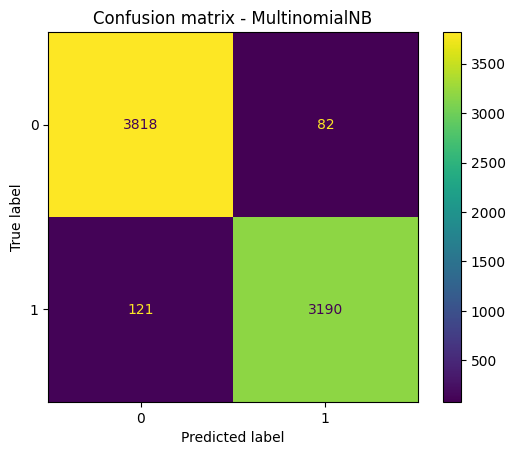


Model: LogisticRegression
Accuracy: 0.9796144778810151
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3900
           1       0.97      0.99      0.98      3311

    accuracy                           0.98      7211
   macro avg       0.98      0.98      0.98      7211
weighted avg       0.98      0.98      0.98      7211



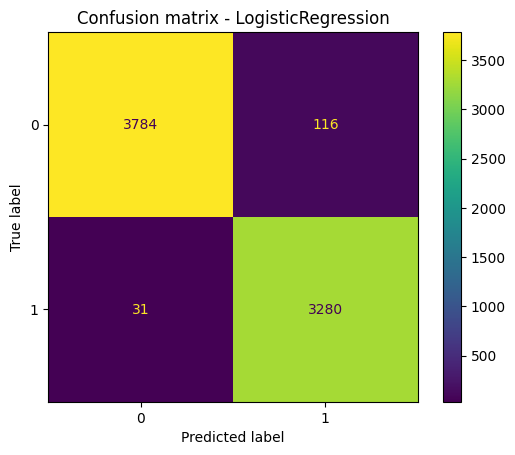


Model: RandomForest
Accuracy: 0.978643738732492
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3900
           1       0.97      0.98      0.98      3311

    accuracy                           0.98      7211
   macro avg       0.98      0.98      0.98      7211
weighted avg       0.98      0.98      0.98      7211



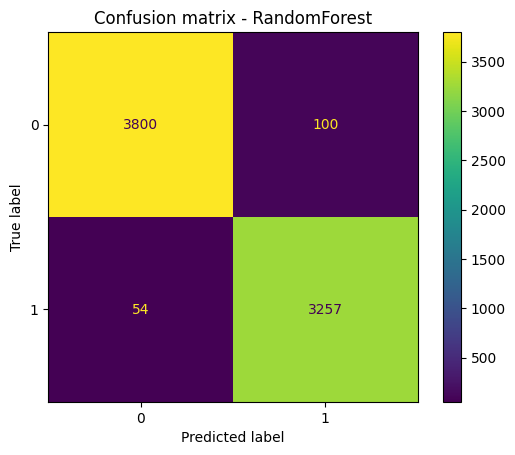

In [17]:
# Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
for name, info in results.items():
    print('\n' + '='*30)
    print('Model:', name)
    print('Accuracy:', info['accuracy'])
    print(classification_report(y_test, info['preds']))
    cm = confusion_matrix(y_test, info['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion matrix - {name}')
    plt.show()

In [18]:
# Save best model as a pipeline (vectorizer + model)
from sklearn.pipeline import Pipeline
best_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
pipeline = Pipeline([('tfidf', vectorizer), ('model', best_model)])

save_path = '/content/drive/MyDrive/ColabNotebooks/best_spam_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(pipeline, f)
print('Saved best model:', best_name, 'to', save_path)

Saved best model: LogisticRegression to /content/drive/MyDrive/ColabNotebooks/best_spam_model.pkl


In [19]:
# Predict helper
def predict_message(message, model_path='/content/drive/MyDrive/ColabNotebooks/best_spam_model.pkl'):
    with open(model_path, 'rb') as f:
        pipe = pickle.load(f)
    pred = pipe.predict([message])[0]
    proba = pipe.predict_proba([message])[0] if hasattr(pipe, 'predict_proba') else None
    return pred, proba

# Example:
# print(predict_message('Congratulations! You won a prize. Click here.'))